**Activity 01** - Data Mining Course
Student: Jansen Rodrigues de Avila
ID: 2102410001

Reference: https://colab.research.google.com/drive/1jk4AQVqGhYY919HfElsEBKIJKBQTFL39?usp=sharing


*   Dataset
Relatório Fies - Inscrições 1/2021 (https://dadosabertos.mec.gov.br/fies) - **Principal**

**Datasets:**
1. https://dadosabertos.mec.gov.br/images/conteudo/fies/2021/relatorio_inscricao_dados_abertos_fies_12021.csv

---

**Tools**
*   Python (Pandas)
*   Numpy

## Project Specifications
1. Select a dataset for your project. The dataset must have at least one nominal attribute to be predicted.
2. Choose the programming language, libraries, and environment for your project. I strongly suggest Google Colab.
3. Import the chosen dataset into your programming environment.
4. Apply preprocessing techniques to your dataset. Address issues such as missing values, outliers, and scaling.
5. Implement one or more classification algorithms.
6. Use appropriate metrics to evaluate the results provided by the algorithm.
7. Discuss the insights gained from the algorithm's output.
8. Prepare slides to be presented in class. The suggested structure is: 1 slide for identification, 1 slide describing the problem, 1 slide describing the dataset (including samples, attributes, classes, and data types), 1 slide presenting the model, 1 slide presenting the decision surface (if applicable), 1 slide presenting the confusion matrix, and 1 slide containing your conclusions


- To-do:

**Pré-processing.**
- Verificar os dados que são realmente relevantes
- Verificar os dados que estão duplicados (só mudam o curso)
- Possíveis erros de português.












**Dataset Importation and Preprocessing**

In [1]:
!pip install gdown # para fazer download do dataset direto do google drive, arquivo > 100MB

In [2]:
import pandas as pd
import numpy as np
import gdown
from matplotlib import pyplot as plt
import seaborn as sns

link = "https://drive.google.com/file/d/1RRbqdUvZO4koiNMusWGsBTNzBDu3RQrf/view?usp=drive_link"
gdown.download(url=link, output="relatorio_fies.csv", fuzzy=True)

dataset = pd.read_csv("relatorio_fies.csv", header=0, encoding='latin1', delimiter=';')

dropColumns = [
    'Ano do processo seletivo',
    'Semestre do processo seletivo',
    'Cod. do Grupo de preferência',
    'Municipio de residência',
    'Professor rede pública ensino?',
    'Cod.Microrregião',
    'Microrregião',
    'Cod.Mesorregião',
    'Mesorregião',
    'Opções de cursos da inscrição',
    'Nome mantenedora',
    'Natureza Jurídica Mantenedora',
    'CNPJ da mantenedora',
    'Código e-MEC da Mantenedora',
    'Nome da IES',
    'Código e-MEC da IES',
    'Organização Acadêmica da IES',
    'Município da IES',
    'UF da IES',
    'Nome do Local de oferta',
    'Código do Local de Oferta',
    'Munícipio do Local de Oferta',
    'UF do Local de Oferta',
    'Código do curso',
    'Percentual de financiamento',
    'Semestre do financiamento', # Excluída para evitar o Data Leakage - pode ser usada para estudo mais tarde.
    'Qtde semestre financiado' # Excluída para evitar o Data Leakage - pode ser usada para estudo mais tarde.
]

cleanDf = dataset.drop(dropColumns, axis=1) # Remove as colunas que não vão ser utilizadas no dataset.

Downloading...
From (original): https://drive.google.com/uc?id=1RRbqdUvZO4koiNMusWGsBTNzBDu3RQrf
From (redirected): https://drive.google.com/uc?id=1RRbqdUvZO4koiNMusWGsBTNzBDu3RQrf&confirm=t&uuid=7c37c62f-243b-40a1-b794-88d322bbbab5
To: /content/relatorio_fies.csv
100%|██████████| 145M/145M [00:01<00:00, 105MB/s]


**Preprocessing**

In [3]:
# Conversão de Dados (Data Casting)
# Troca todos os valores ausentes na renda familiar mensal bruta por 0 e passa para float
if 'Renda familiar mensal bruta' in cleanDf.columns:
  cleanDf['Renda familiar mensal bruta'] = cleanDf['Renda familiar mensal bruta'].fillna(0)
  cleanDf['Renda familiar mensal bruta'] = cleanDf['Renda familiar mensal bruta'].astype(str).str.replace(',', '.').astype(float)

objToFloat = ['Renda mensal bruta per capita','Conceito de curso do GP','Nota Corte Grupo Preferência','Conceito','Média nota Enem','Ano do Enem','Redação','Matemática e suas Tecnologias','Linguagens, Códigos e suas Tec','Ciências Natureza e suas Tec','Ciências Humanas e suas Tec','Semestre do financiamento','Qtde semestre financiado']
#objToInt = ['Conceito de curso do GP', 'Conceito','Ano do Enem', 'Semestre do financiamento','Qtde semestre financiado']
for col in objToFloat:
  if col in cleanDf.columns:
    cleanDf[col] = cleanDf[col].astype(str).str.replace(',', '.', regex=False)
    #cleanDf[col] = cleanDf[col].astype(str).str.replace(' ', '0', regex=False)
    cleanDf[col] = pd.to_numeric(cleanDf[col], errors='coerce')

cleanDf = cleanDf.drop_duplicates(subset=['ID do estudante'], keep='first') # Deixa apenas a primeira opção escolhida pelo estudante.

cleanDf['Conceito'] = cleanDf['Conceito'].fillna(3) # Mudança aos que estavam com a situação "Autorizado" pois são novos cursos
cleanDf['Conceito de curso do GP'] = cleanDf['Conceito de curso do GP'].fillna(3) # Mudança aos que estavam com a situação "Autorizado" pois são novos cursos
# Para os valores vazios na 'Nota Corte Grupo Preferência', será a média com o agrupamento feito do Conceito, Área do Conhecimento e Subárea do Conhecimento iguais.
cleanDf['Nota Corte Grupo Preferência'] = cleanDf.groupby(['Conceito de curso do GP', 'Área do conhecimento', 'Subárea do conhecimento'])['Nota Corte Grupo Preferência'].transform(lambda x: x.fillna(x.mean()))

# Incluir coluna de idade?

finalDf = cleanDf
finalDf.info()


<class 'pandas.core.frame.DataFrame'>
Index: 128822 entries, 0 to 257742
Data columns (total 32 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Classificação                         128822 non-null  int64  
 1   ID do estudante                       128822 non-null  int64  
 2   Sexo                                  128822 non-null  object 
 3   Data de Nascimento                    128822 non-null  object 
 4   UF de residência                      128822 non-null  object 
 5   Etnia/Cor                             128822 non-null  object 
 6   Pessoa com deficiência?               128822 non-null  object 
 7   Concluiu ensino médio escola pública  128822 non-null  object 
 8   Ano conclusão ensino médio            128822 non-null  int64  
 9   Concluiu curso superior?              128822 non-null  object 
 10  Beneficiado pelo Creduc ou Fies       128822 non-null  object 
 11  Nº de

**Descriptive Statistics**

Conjunto de estatísticas descritivas específicas do dataset após ter sido realizado o pré processamento.



In [4]:
# Os mais simples
##### Para as pessoas
# Média de idade dos estudantes no momento da aplicação # Se eu incluir ali em cima dá pra fazer.
# UF de residência (Ok)
# Etnia (Ok)
# PCD (Ok)
# Concluiu ensino médio em escola pública (Ok)
# Renda familiar (média) (Ok)
# Média nota do enem (Ok).
# Ano de realização. (Ok)

mediaEnem = finalDf['Média nota Enem'].mean() # Float numpy
mediaRendaFam = finalDf['Renda familiar mensal bruta'].mean() # Float numpy
ufResidencia = finalDf['UF de residência'].value_counts().head(3).index # Retorna série
anoEnem = finalDf['Ano do Enem'].value_counts().head(3) # Retorna série
conclusaoEnsPub = finalDf['Concluiu ensino médio escola pública'].value_counts().index # Retorna série
numPCD = finalDf['Pessoa com deficiência?'].value_counts().index # Retorna série
numEtnia = finalDf['Etnia/Cor'].value_counts().index # Retorna série

##### Para as faculdades
# Região do grupo de preferência (Ok)
# Áreas do conhecimento (Ok)
# UF da IES (Ok)
# Nome dos cursos (talvez, são vários, mostrar top 5 se der)

regiaoGpPref = finalDf['Região grupo de preferência'].value_counts().head(3).index
nomeCurso = finalDf['Nome do curso'].value_counts().head(5).index


##### Geral
# Situação de Inscrição do FIES (Contratados e etc) (Ok)
sitGeral = finalDf['Situação Inscrição Fies'].value_counts().index

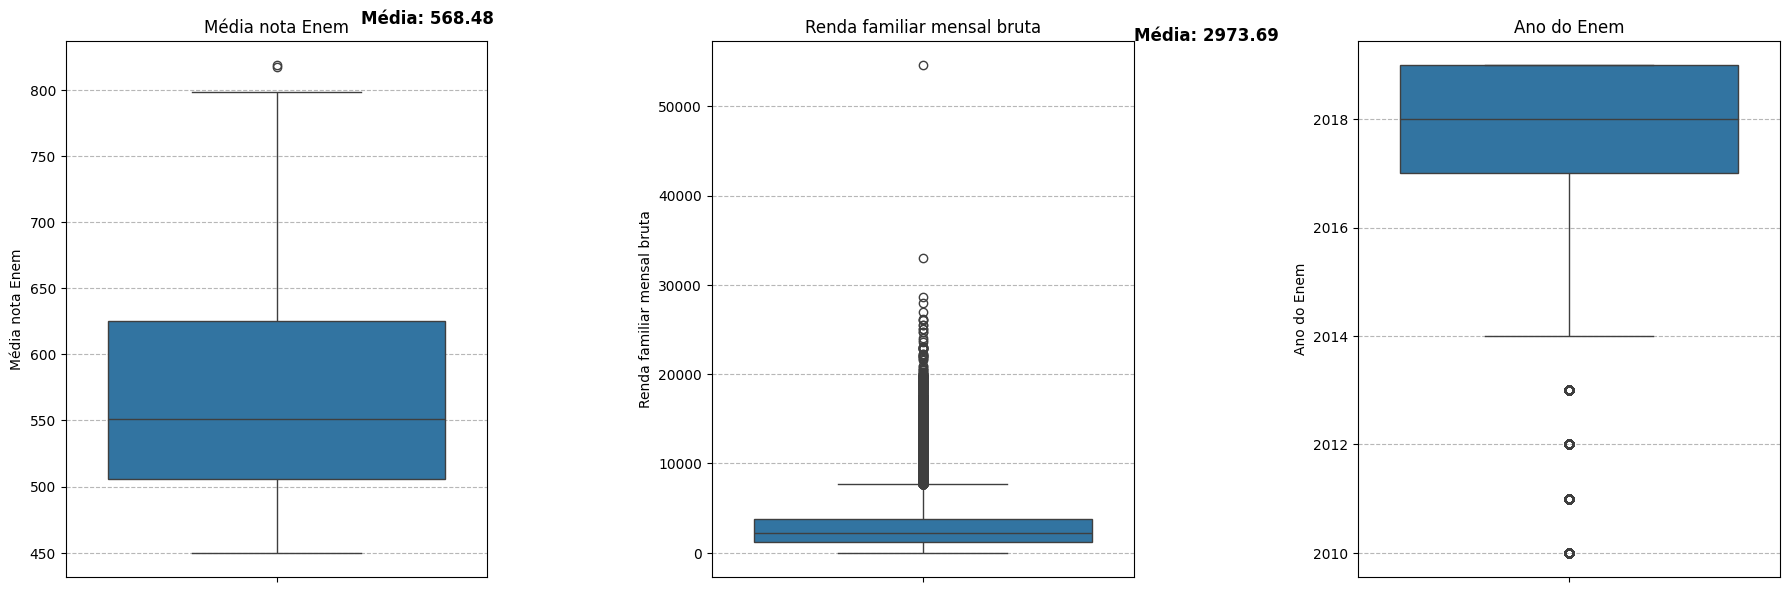

In [5]:
# Boxplots para colunas numéricas
# Separamos as colunas numéricas para o boxplot, pois plt.boxplot não pode processar dados de texto.

boxplotNum = [finalDf['Média nota Enem'], finalDf['Renda familiar mensal bruta'], finalDf['Ano do Enem']]
labels = ['Média nota Enem', 'Renda familiar mensal bruta', 'Ano do Enem']

fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Increased figsize for better visibility

# Plot - Média nota Enem
sns.boxplot(y=finalDf['Média nota Enem'], ax=axes[0])
axes[0].set_title(labels[0])
axes[0].set_ylabel(labels[0]) # Set y-axis label
axes[0].grid(axis='y', linestyle='--', alpha=0.9)
axes[0].text(x=0.20, y=850, s='Média: {:.2f}'.format(mediaEnem),
             fontsize=12, color='black', fontweight='bold')

# Plot - Renda familiar mensal bruta
sns.boxplot(y=finalDf['Renda familiar mensal bruta'], ax=axes[1])
axes[1].set_title(labels[1])
axes[1].set_ylabel(labels[1])
axes[1].grid(axis='y', linestyle='--', alpha=0.9)
axes[1].text(x=1.0, y=1.0, s='Média: {:.2f}'.format(mediaRendaFam),
             fontsize=12, color='black', fontweight='bold',transform=axes[1].transAxes)

# Plot - Ano do Enem
sns.boxplot(y=finalDf['Ano do Enem'], ax=axes[2])
axes[2].set_title(labels[2])
axes[2].set_ylabel(labels[2])
axes[2].grid(axis='y', linestyle='--', alpha=0.9)
#axes[2].text(x=0.20, y=850, s='Anos:'.format(anoEnem),
#             fontsize=12, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4059/2029624074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='UF de residência', data=finalDf, order=ufResidencia, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_4059/2029624074.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Concluiu ensino médio escola pública', data=finalDf, order=conclusaoEnsPub, ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_4059/2029624074.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pessoa com deficiência?', data=finalDf, order=numPCD, ax=axes[1, 0], palette='Blues')
/t

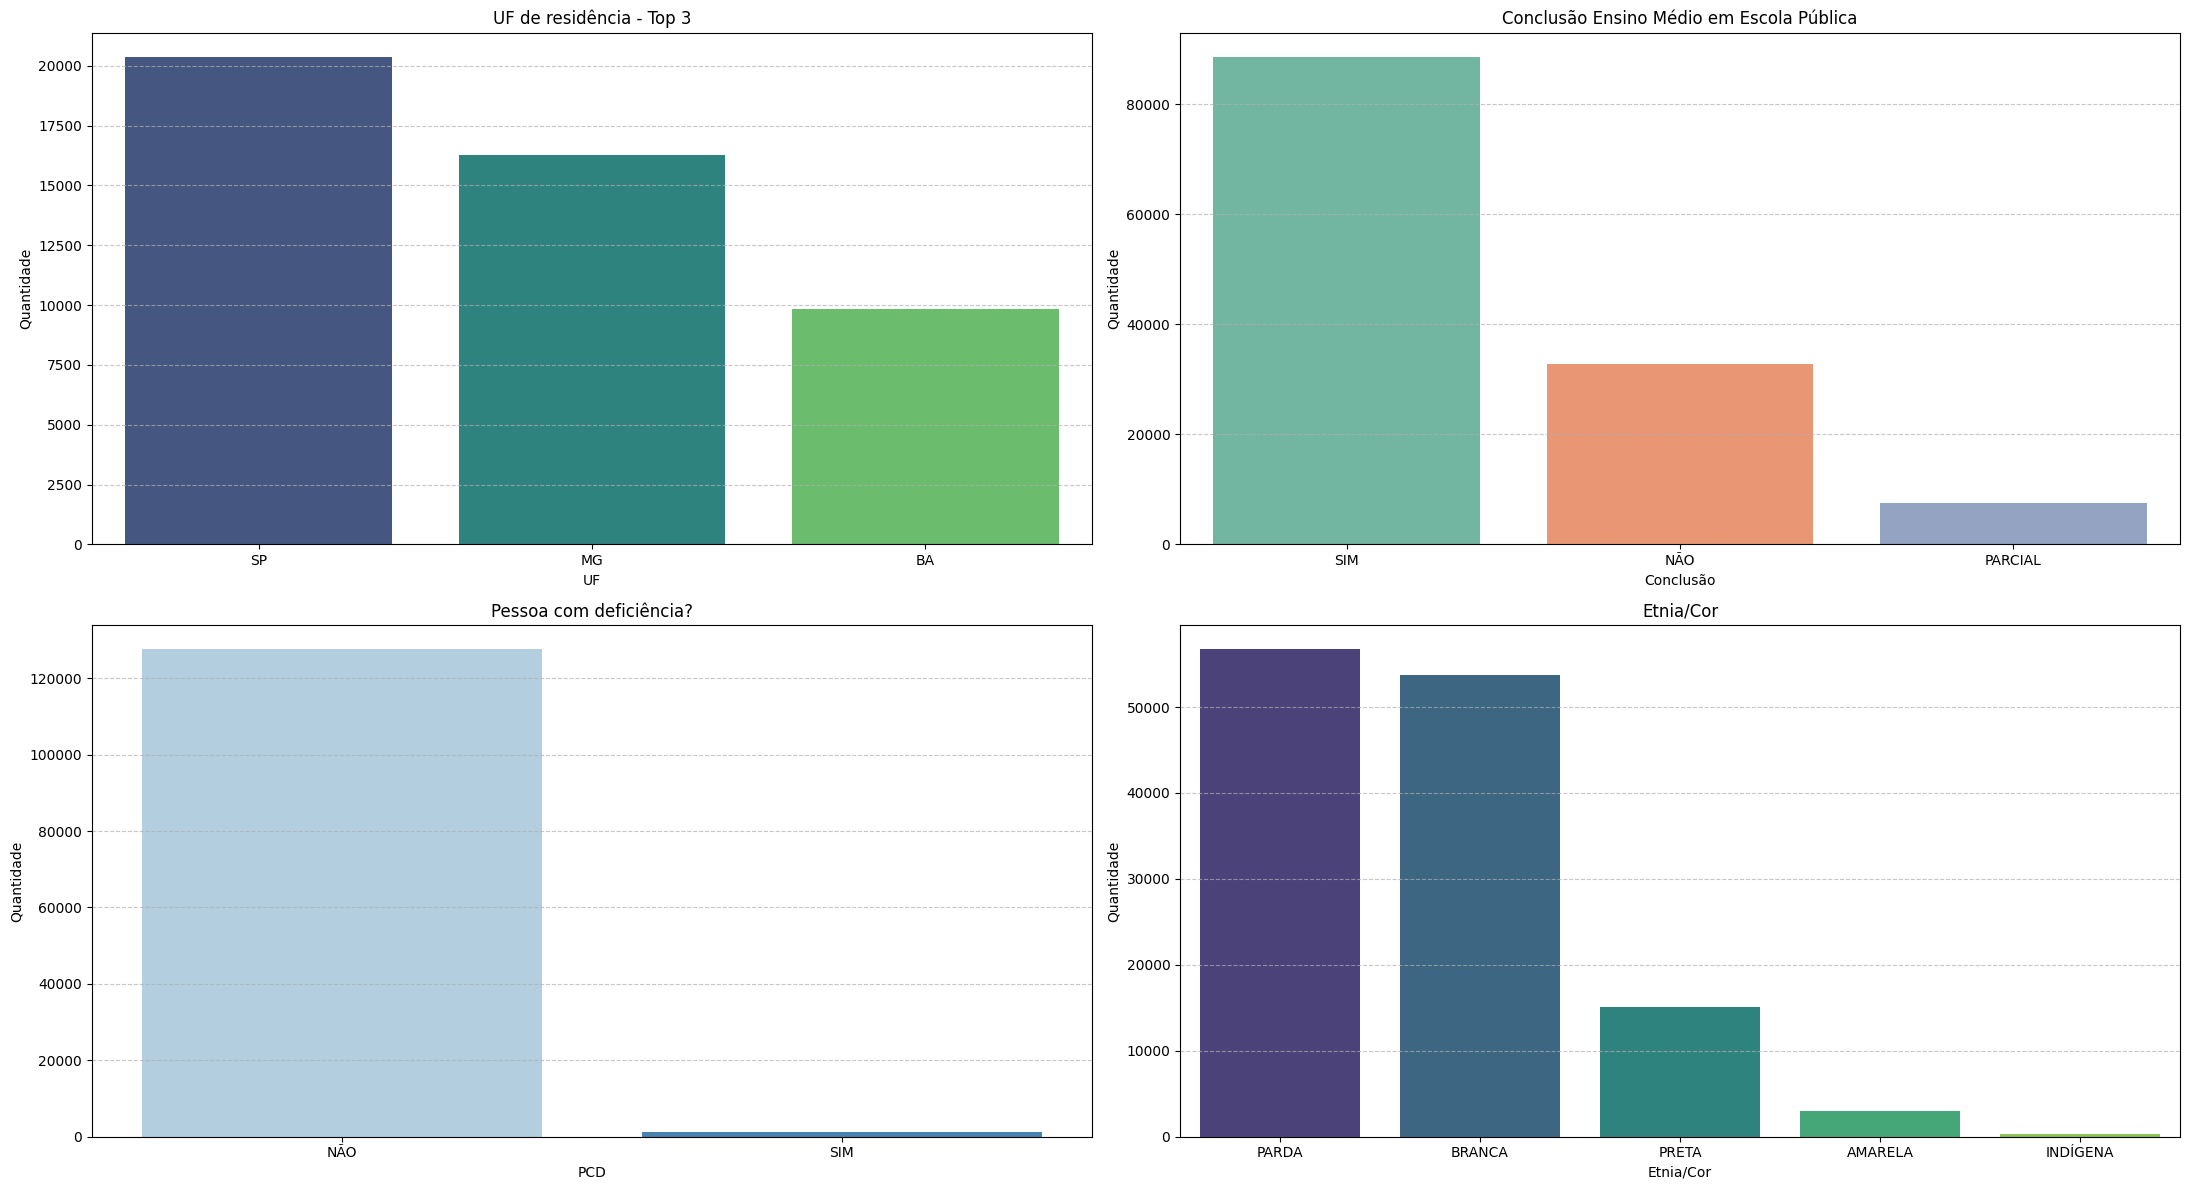

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(22, 12))

sns.countplot(x='UF de residência', data=finalDf, order=ufResidencia, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('UF de residência - Top 3')
axes[0, 0].set_xlabel('UF')
axes[0, 0].set_ylabel('Quantidade')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

sns.countplot(x='Concluiu ensino médio escola pública', data=finalDf, order=conclusaoEnsPub, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Conclusão Ensino Médio em Escola Pública')
axes[0, 1].set_xlabel('Conclusão')
axes[0, 1].set_ylabel('Quantidade')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

sns.countplot(x='Pessoa com deficiência?', data=finalDf, order=numPCD, ax=axes[1, 0], palette='Blues')
axes[1, 0].set_title('Pessoa com deficiência?')
axes[1, 0].set_xlabel('PCD')
axes[1, 0].set_ylabel('Quantidade')
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

sns.countplot(x='Etnia/Cor', data=finalDf, order=numEtnia, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Etnia/Cor')
axes[1, 1].set_xlabel('Etnia/Cor')
axes[1, 1].set_ylabel('Quantidade')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4059/211006136.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Região grupo de preferência', data=finalDf, order=regiaoGpPref, ax=axes[0], palette='viridis')
/tmp/ipykernel_4059/211006136.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Nome do curso', data=finalDf, order=nomeCurso, ax=axes[1], palette='Blues')


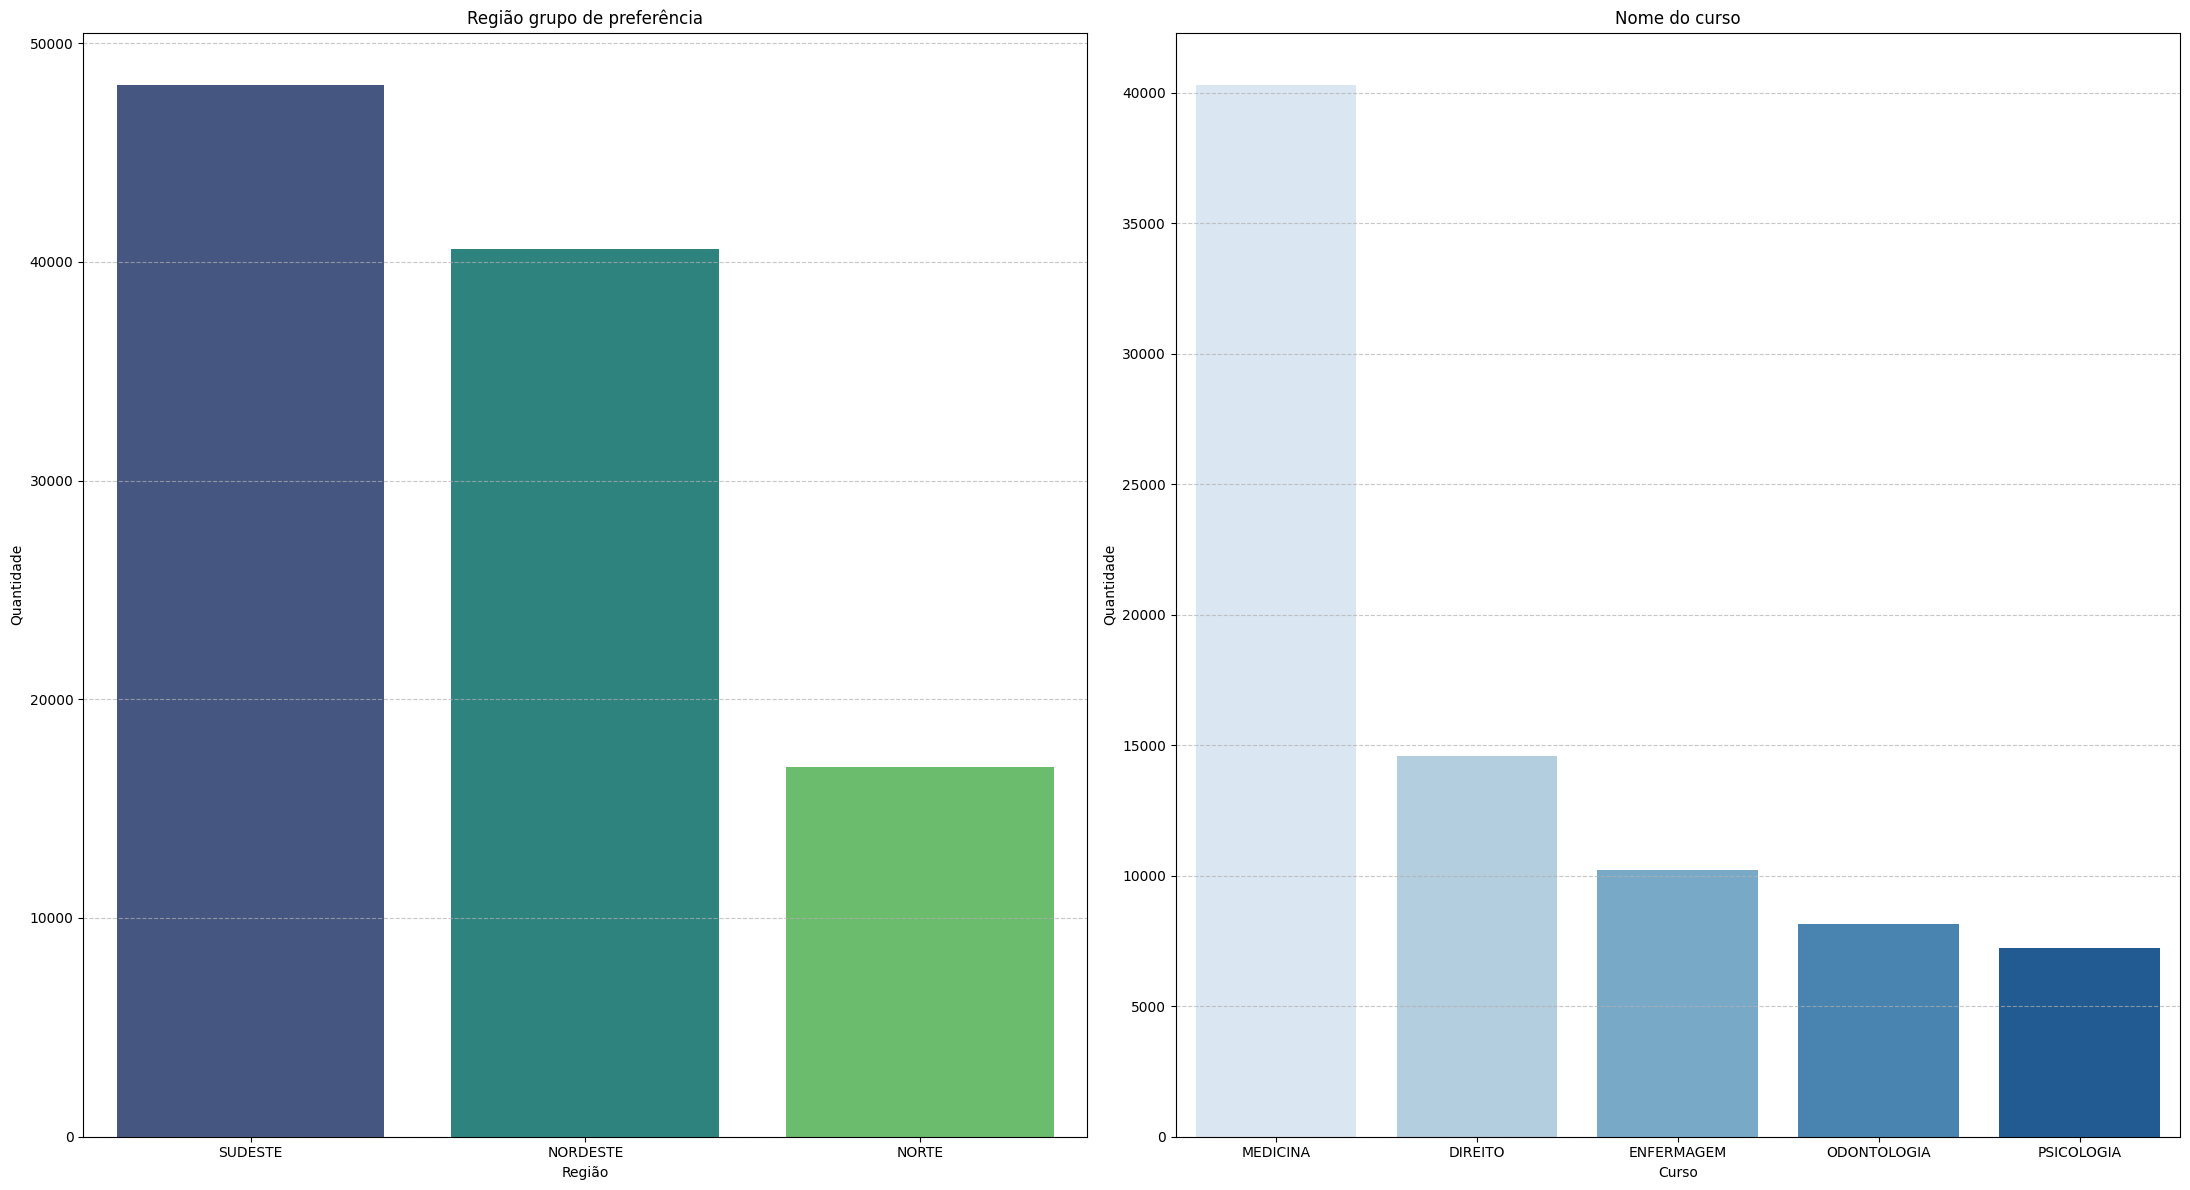

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(22, 12))

sns.countplot(x='Região grupo de preferência', data=finalDf, order=regiaoGpPref, ax=axes[0], palette='viridis')
axes[0].set_title('Região grupo de preferência')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Quantidade')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.countplot(x='Nome do curso', data=finalDf, order=nomeCurso, ax=axes[1], palette='Blues')
axes[1].set_title('Nome do curso')
axes[1].set_xlabel('Curso')
axes[1].set_ylabel('Quantidade')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4059/658692007.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Situação Inscrição Fies', data=finalDf, order=sitGeral, palette='viridis')


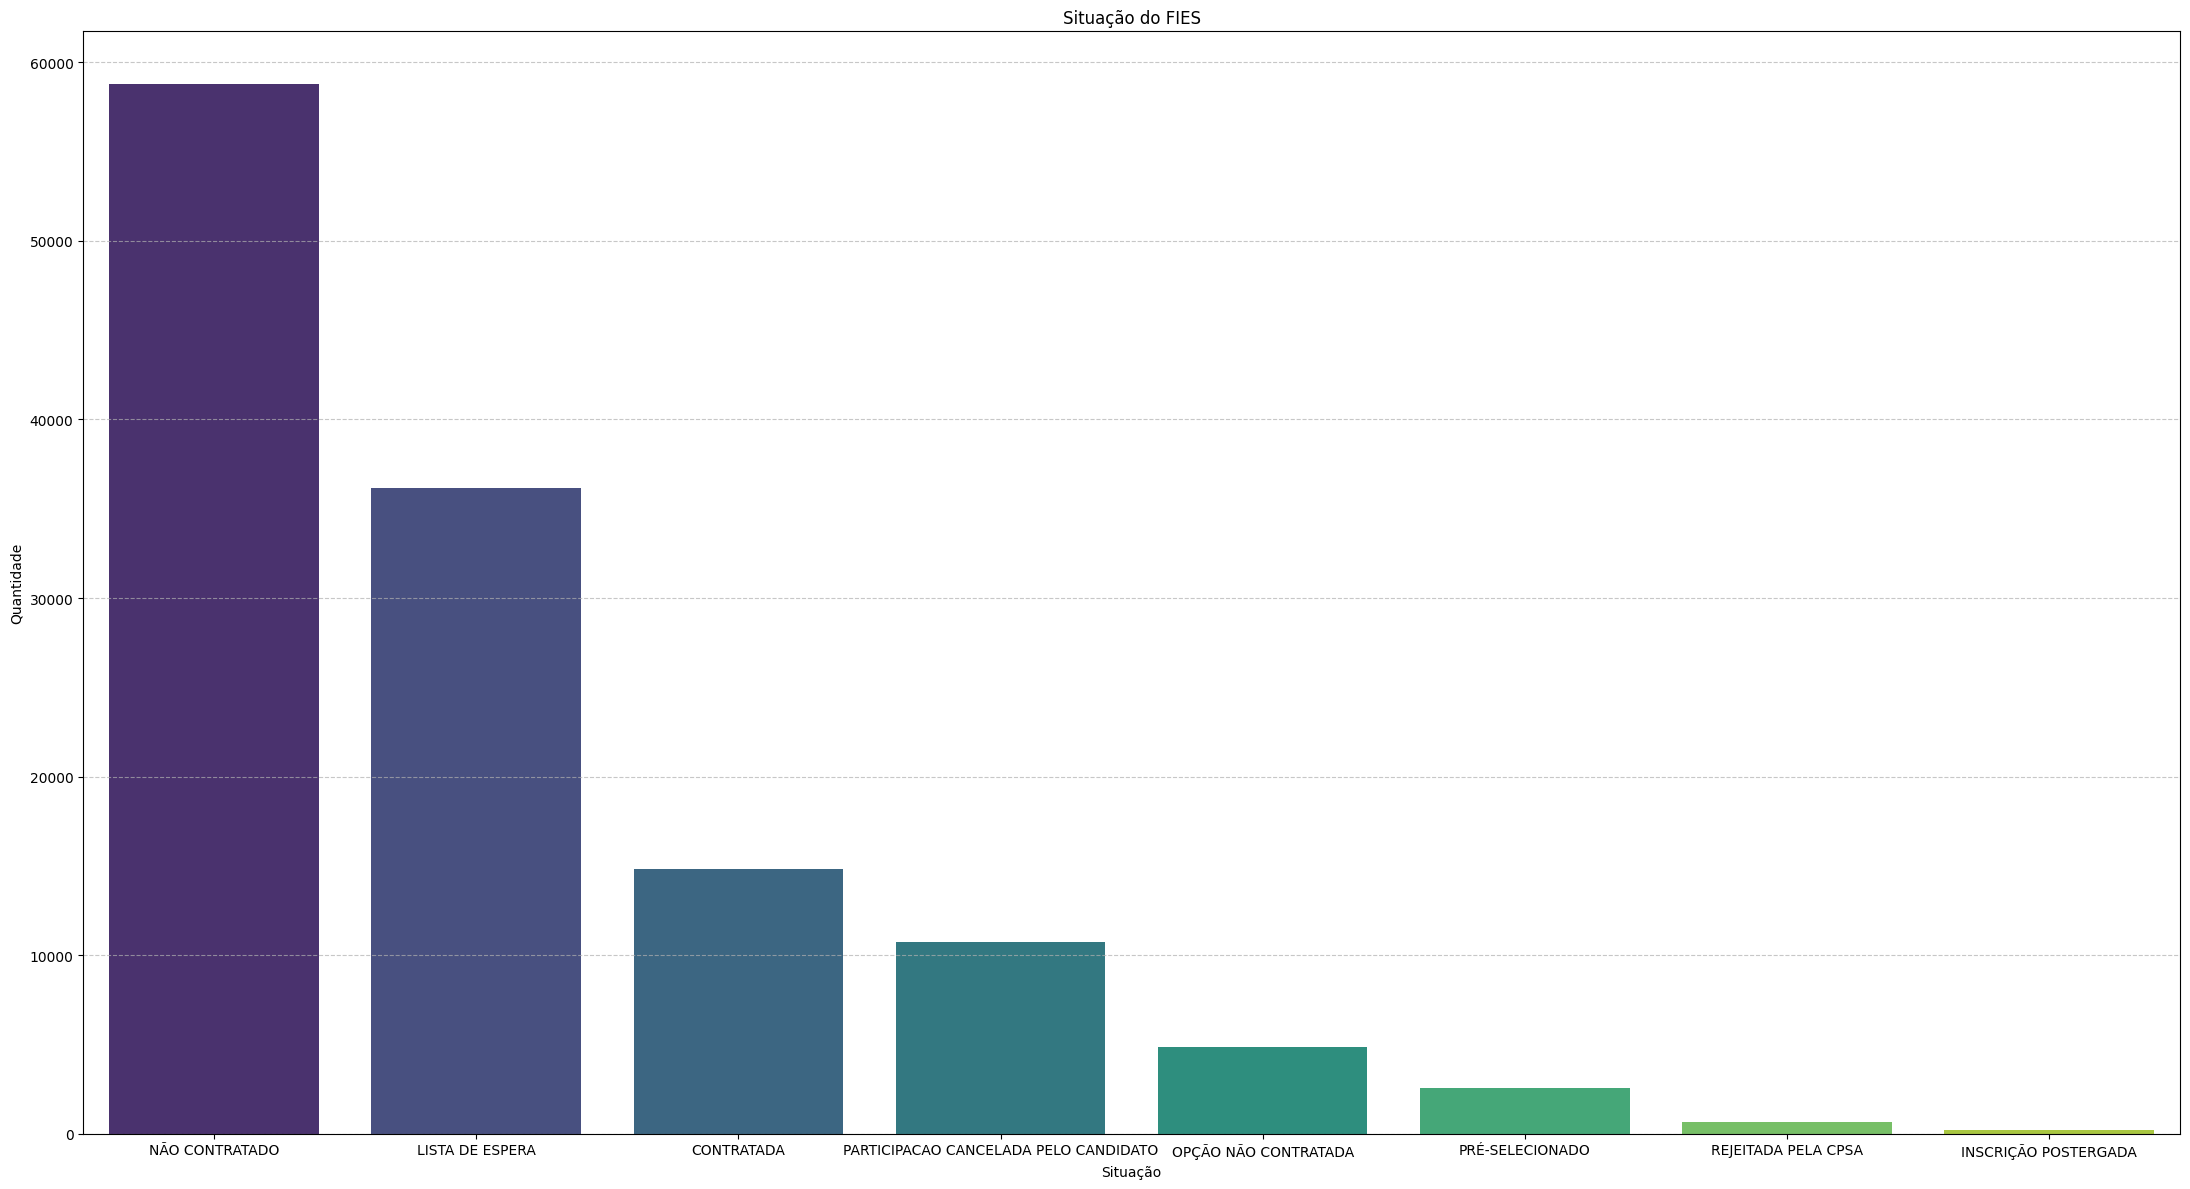

In [8]:
# Situação do FIES antes do preprocessing.

fig, axes = plt.subplots(1, figsize=(22, 12))

sns.countplot(x='Situação Inscrição Fies', data=finalDf, order=sitGeral, palette='viridis')
axes.set_title('Situação do FIES')
axes.set_xlabel('Situação')
axes.set_ylabel('Quantidade')
axes.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4059/622593305.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Situação Inscrição Fies', data=finalDf, order=sitGeral, palette='viridis')


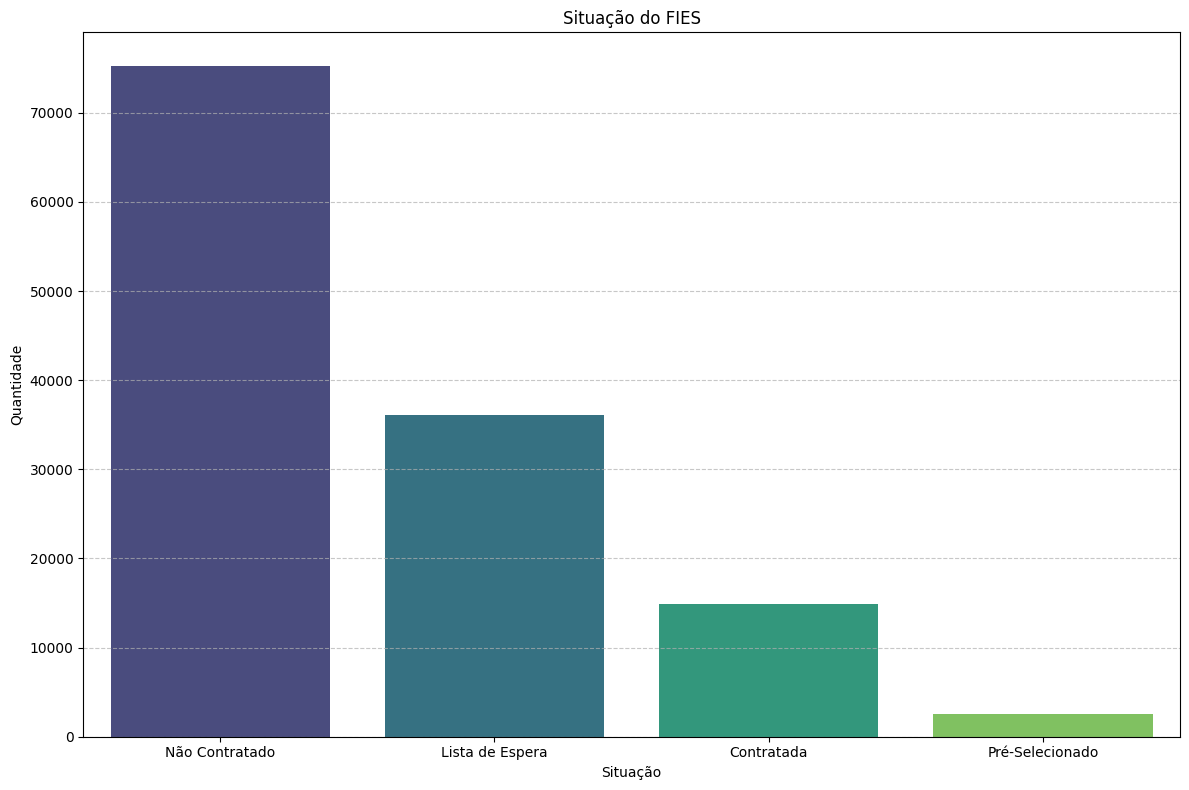

In [9]:
finalDf['Situação Inscrição Fies'] = finalDf['Situação Inscrição Fies'].astype(str).str.strip().str.upper()
mapeamentoSituacao = {
    # Grupo: Não Contratado
    'NÃO CONTRATADO': 'Não Contratado',
    'PARTICIPACAO CANCELADA PELO CANDIDATO': 'Não Contratado',
    'OPÇÃO NÃO CONTRATADA': 'Não Contratado',
    'REJEITADA PELA CPSA': 'Não Contratado',
    'INSCRIÇÃO POSTERGADA': 'Não Contratado',

    # Grupo: Mantidos "como estão" (Apenas ajustando para Title Case por estética)
    'CONTRATADA': 'Contratada',
    'PRÉ-SELECIONADO': 'Pré-Selecionado',
    'LISTA DE ESPERA': 'Lista de Espera'
}

finalDf['Situação Inscrição Fies'] = finalDf['Situação Inscrição Fies'].map(mapeamentoSituacao)
sitGeral = finalDf['Situação Inscrição Fies'].value_counts().index
fig, axes = plt.subplots(1, figsize=(12, 8))

sns.countplot(x='Situação Inscrição Fies', data=finalDf, order=sitGeral, palette='viridis')
axes.set_title('Situação do FIES')
axes.set_xlabel('Situação')
axes.set_ylabel('Quantidade')
axes.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Algoritmos de Classificação**

O intuíto da classificação é prever a label ***Situação Inscrição FIES*** dos candidatos.

Os algoritmos de classificação que foram utilizados neste trabalho foram:

**- Árvore de Decisão (Decision Tree)**: Faz a divisão em perguntas sequenciais.

**- KNN**: Com o contexto de similaridade, plota os alunos em um espaço matemático.

**Árvore de Decisão (Decision Tree)** - Geral

In [10]:
from sklearn import tree, model_selection
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

X = finalDf.drop(columns=['Situação Inscrição Fies', 'ID do estudante']) # Inputs para a árvore
y = finalDf['Situação Inscrição Fies'] # Saída buscada (saber a situação que o estudante vai estar)

X = pd.get_dummies(X, drop_first=True) # Transforma os dados categóricos em numéricos (0 ou 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y) # Split arrays or matrices into random train and test subsets.
# Divisão: Holdout: 70% / Teste: 30%
# Stratify garante que a proporção de cada classe seja a mesma no treino e no teste.


print("Dimensões do training (inputs) dataset: ", X_train.shape)
print("Dimensões do testing (inputs) dataset: ", X_test.shape)
print("Dimensões do training (outputs) dataset: ", y_train.shape)
print("Dimensões do testing (outputs) dataset: ", y_test.shape)

clf_tree = tree.DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=5, random_state=42)
# Max_depth = 5. Evita o overfitting decorando os dados e foca nos padrões reais. Como forçar a árvore a parar no 5º nível, se não vai aprender sobre todos os candidatos
# Criterion= 'gini'. Critério para julgar se a decisão foi boa ou não (mede a impureza/entropia).
# Splitter= 'best'. Estratégia de busca para encontrar "quebras".

# Treinando da árvore de decisão.
clf_tree = clf_tree.fit(X_train, y_train)

# Previsão nos dados. Verifica se a predição se de acordo com os testes.
y_pred = clf_tree.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
taxa_erro = 1 - acuracia

print("📊 RESULTADOS DA AVALIAÇÃO DO MODELO")
print(f"🎯 Acurácia: {acuracia * 100:.2f}%")
print(f"⚠️ Taxa de Erro: {taxa_erro * 100:.2f}%\n")

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))


Dimensões do training (inputs) dataset:  (90175, 11413)
Dimensões do testing (inputs) dataset:  (38647, 11413)
Dimensões do training (outputs) dataset:  (90175,)
Dimensões do testing (outputs) dataset:  (38647,)
📊 RESULTADOS DA AVALIAÇÃO DO MODELO
🎯 Acurácia: 82.18%
⚠️ Taxa de Erro: 17.82%

[[   72   122  4262     0]
 [    1  9887   954     0]
 [   79   698 21800     0]
 [    3     6   763     0]]
                 precision    recall  f1-score   support

     Contratada       0.46      0.02      0.03      4456
Lista de Espera       0.92      0.91      0.92     10842
 Não Contratado       0.78      0.97      0.87     22577
Pré-Selecionado       0.00      0.00      0.00       772

       accuracy                           0.82     38647
      macro avg       0.54      0.47      0.45     38647
   weighted avg       0.77      0.82      0.77     38647



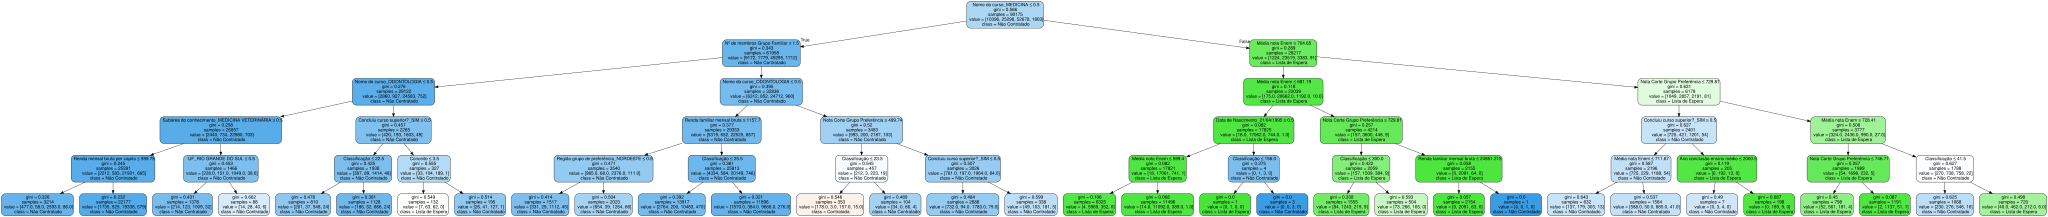

In [11]:
# Plot - Árvore de Decisão.
import graphviz
from sklearn.tree import export_graphviz

dot_data = export_graphviz(
    clf_tree,                      # Modelo
    out_file=None,                 # Mostra direto no colab, sem salvar em arquivo de saída
    feature_names=X_train.columns, # Nomes exatos das colunas (com as Dummies da UF/Sexo)
    class_names=clf_tree.classes_, # Os 4 status dinâmicos (Aprovado, Não Contratado, etc.)
    filled=True,                   # Pinta o fundo das caixinhas com cores indicando a classe
    rounded=True,                  # Arredonda as bordas das caixinhas
    special_characters=True        # Permite acentuação e caracteres especiais nos textos
)

grafico_arvore = graphviz.Source(dot_data)
# grafico_arvore.render("iris-color")
grafico_arvore.render("arvore_fies_final", format="png", cleanup=True)
grafico_arvore


In [12]:
# Avaliação de Desempenho
# Training set x Test set

# Training
y_pred_train = clf_tree.predict(X_train)
acuracia_treino = accuracy_score(y_train, y_pred_train)
erro_treino = 1 - acuracia_treino
tmpdata = X_train.copy()
tmpdata['Situação Inscrição Fies'] = y_train.values

# Test
y_pred_test = clf_tree.predict(X_test)
acuracia_teste = accuracy_score(y_test, y_pred_test)
erro_teste = 1 - acuracia_teste
tmpdataTwo = X_test.copy()
tmpdataTwo['Situação Inscrição Fies'] = y_test.values

print("📊 RESULTADOS - TRAINING X TEST")
print(f"🎯 Acurácia - Treino: {acuracia_treino * 100:.2f}%")
print(f"🎯 Acurácia - Teste: {acuracia_teste * 100:.2f}%")
print(f"⚠️ Taxa de Erro - Treino: {erro_treino * 100:.2f}%")
print(f"⚠️ Taxa de Erro - Teste: {erro_teste * 100:.2f}%\n")

📊 RESULTADOS - TRAINING X TEST
🎯 Acurácia - Treino: 82.14%
🎯 Acurácia - Teste: 82.18%
⚠️ Taxa de Erro - Treino: 17.86%
⚠️ Taxa de Erro - Teste: 17.82%



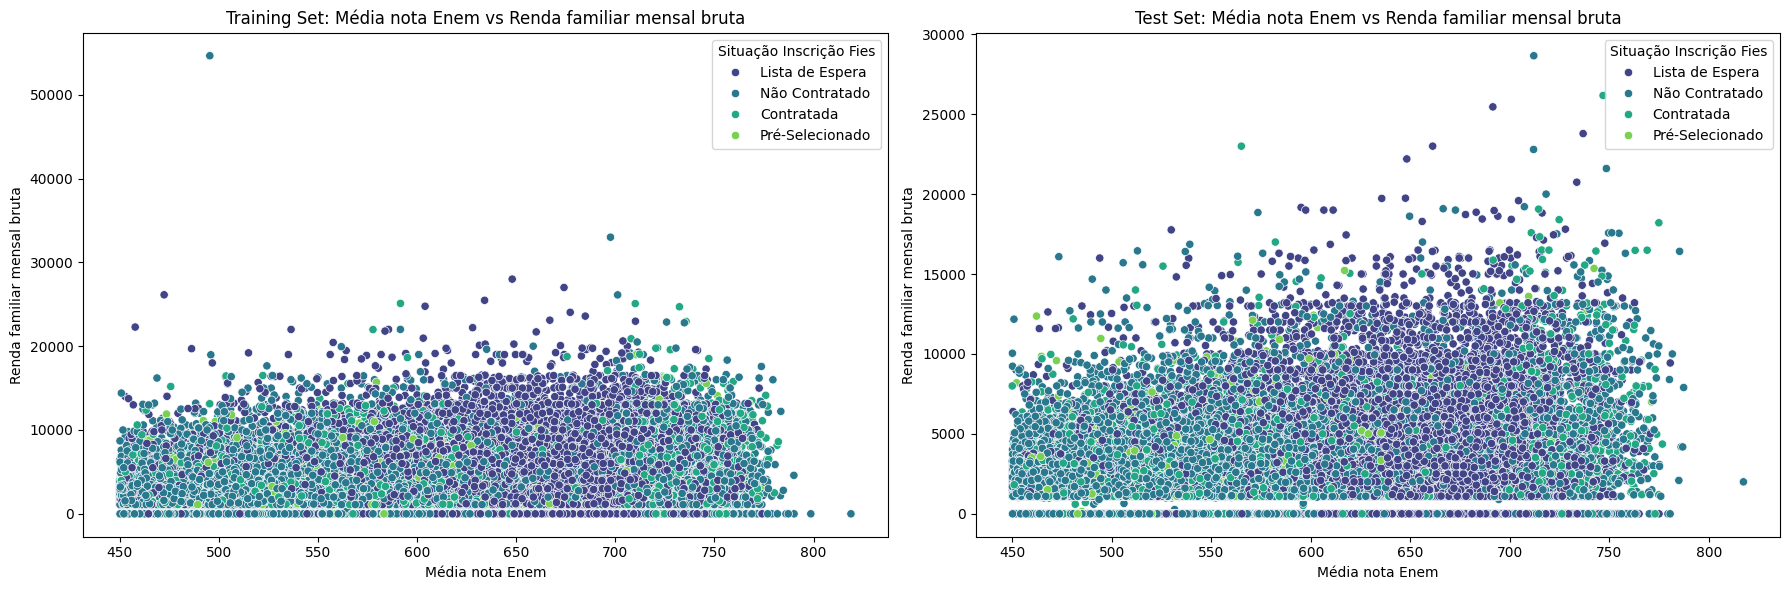

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scatter plot for training data
sns.scatterplot(x='Média nota Enem', y='Renda familiar mensal bruta', data=tmpdata, hue='Situação Inscrição Fies', palette='viridis', ax=axes[0])
axes[0].set_title('Training Set: Média nota Enem vs Renda familiar mensal bruta')
axes[0].set_xlabel('Média nota Enem')
axes[0].set_ylabel('Renda familiar mensal bruta')
axes[0].legend(title='Situação Inscrição Fies')

# Scatter plot for test data
sns.scatterplot(x='Média nota Enem', y='Renda familiar mensal bruta', data=tmpdataTwo, hue='Situação Inscrição Fies', palette='viridis', ax=axes[1])
axes[1].set_title('Test Set: Média nota Enem vs Renda familiar mensal bruta')
axes[1].set_xlabel('Média nota Enem')
axes[1].set_ylabel('Renda familiar mensal bruta')
axes[1].legend(title='Situação Inscrição Fies')

plt.tight_layout()
plt.show()

In [14]:
# Matrizes de Confusão e Métricas

print("Confusion Matrix Train Set:\n",confusion_matrix(y_train, y_pred_train))
print("Classificação Training Set:\n", classification_report(y_train, y_pred_train, zero_division=0))
print(f"="*100)
print("Confusion Matrix Test Set:\n", confusion_matrix(y_test, y_pred_test))
print("Classificação Test Set:\n", classification_report(y_test, y_pred_test, zero_division=0))

Confusion Matrix Train Set:
 [[  178   276  9942     0]
 [    3 23074  2221     0]
 [  157  1703 50818     0]
 [   15    21  1767     0]]
Classificação Training Set:
                  precision    recall  f1-score   support

     Contratada       0.50      0.02      0.03     10396
Lista de Espera       0.92      0.91      0.92     25298
 Não Contratado       0.78      0.96      0.87     52678
Pré-Selecionado       0.00      0.00      0.00      1803

       accuracy                           0.82     90175
      macro avg       0.55      0.47      0.45     90175
   weighted avg       0.77      0.82      0.77     90175

Confusion Matrix Test Set:
 [[   72   122  4262     0]
 [    1  9887   954     0]
 [   79   698 21800     0]
 [    3     6   763     0]]
Classificação Test Set:
                  precision    recall  f1-score   support

     Contratada       0.46      0.02      0.03      4456
Lista de Espera       0.92      0.91      0.92     10842
 Não Contratado       0.78      0.97    

- Support (A Realidade dos Dados)
Essa é a coluna mais fácil. Ela mostra quantos alunos realmente existiam naquela classe dentro dos seus 30% de dados de teste.
- Precision: O quão preciso foi o meu modelo, ou seja, de todos que foram aprovados pelo modelo, quem realmente foi?
- Recall (Sensibilidade): De todos aprovados, quem ele conseguiu achar?
- F1-Score (A Nota Média da Classe): Média harmônica entre o Precision e o Recall. Trabalho do modelo para o referido grupo.

/tmp/ipykernel_4059/4116423947.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


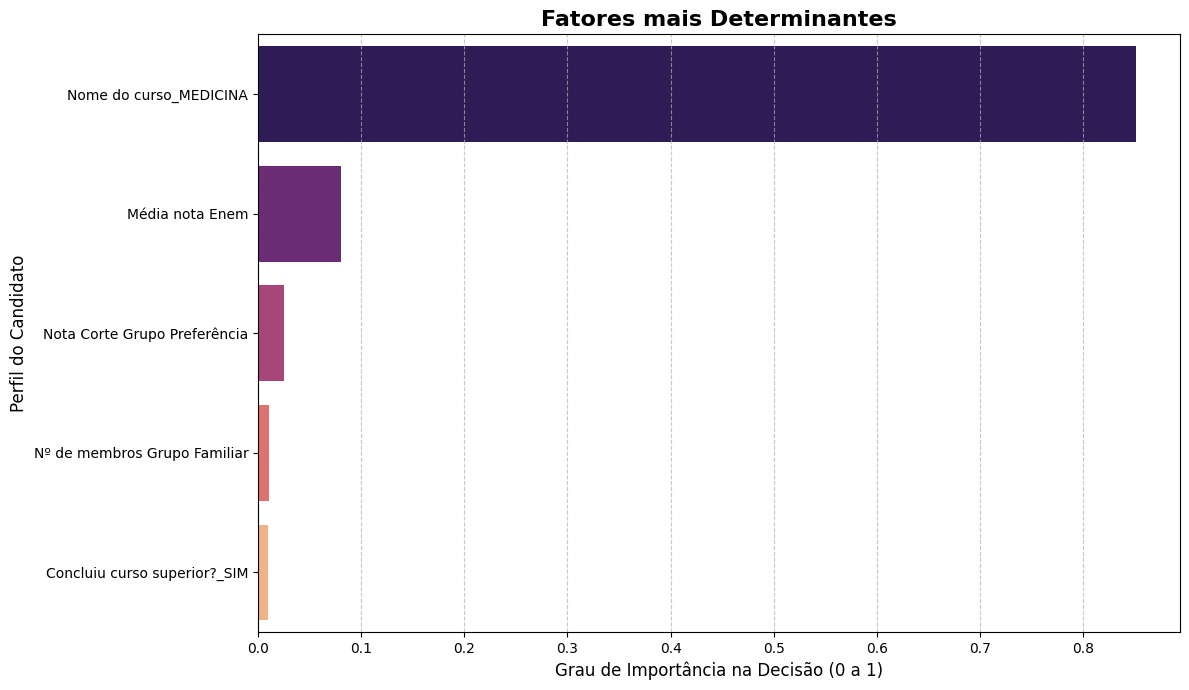

In [15]:
# Importância da Features

# 1. Extraindo as importâncias matemáticas calculadas pela árvore
importancias = clf_tree.feature_importances_
nomes_features = X_train.columns

# 2. Criando um DataFrame para organizar do maior para o menor
df_importancia = pd.DataFrame({
    'Atributo': nomes_features,
    'Peso_Matemático': importancias
})

# Vamos pegar apenas os 10 atributos mais fortes para o gráfico não ficar poluído
df_importancia = df_importancia.sort_values(by='Peso_Matemático', ascending=False).head(5)

# 3. Plotando o gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_importancia,
    x='Peso_Matemático',
    y='Atributo',
    palette='magma' # Uma paleta de cores forte para dar impacto visual
)

# 4. Ajustes estéticos para o slide
plt.title("Fatores mais Determinantes", fontsize=16, fontweight='bold')
plt.xlabel("Grau de Importância na Decisão (0 a 1)", fontsize=12)
plt.ylabel("Perfil do Candidato", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Exibe o gráfico
plt.show()

**Árvore de Decisão (Sócio-econômico).**

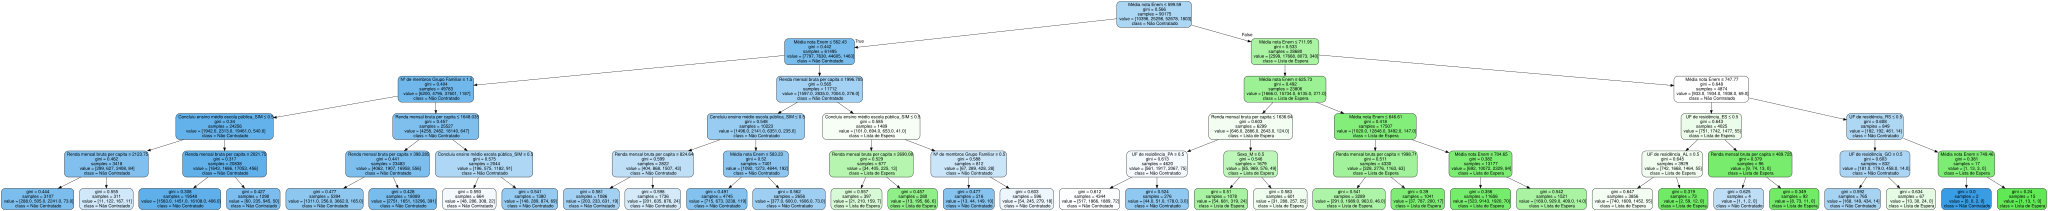

In [16]:
#colunas_socioeconomicas = ['Renda familiar mensal bruta', 'Renda mensal bruta per capita','Etnia/Cor','Sexo','Concluiu ensino médio escola pública',
#                           'Pessoa com deficiência?', 'Média nota Enem', 'UF de residência', 'Concluiu curso superior?', 'Nº de membros Grupo Familiar']

# Diminuição do Feature Selection
colunas_socioeconomicasReduzida = ['Renda mensal bruta per capita','Etnia/Cor','Sexo','Concluiu ensino médio escola pública',
                           'Pessoa com deficiência?', 'UF de residência', 'Nº de membros Grupo Familiar', 'Média nota Enem']

# Filtro dos novos dataframes
Z = finalDf[colunas_socioeconomicasReduzida].copy()
k = finalDf['Situação Inscrição Fies']

# Transformação para 0,1
Z = pd.get_dummies(Z, drop_first=True)

# Separação do training set e do test set
Z_train, Z_test, k_train, k_test = train_test_split(Z, k, test_size=0.30, random_state=42, stratify=y)

clf_tree_social = tree.DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
clf_tree_social.fit(Z_train, k_train)

point_data = export_graphviz(
    clf_tree_social,                      # Modelo
    out_file=None,                 # Mostra direto no colab, sem salvar em arquivo de saída
    feature_names=Z_train.columns, # Nomes exatos das colunas (com as Dummies da UF/Sexo)
    class_names=clf_tree_social.classes_, # Os 4 status dinâmicos (Aprovado, Não Contratado, etc.)
    filled=True,                   # Pinta o fundo das caixinhas com cores indicando a classe
    rounded=True,                  # Arredonda as bordas das caixinhas
    special_characters=True        # Permite acentuação e caracteres especiais nos textos
)

grafico_arvore = graphviz.Source(point_data)
# grafico_arvore.render("iris-color")
grafico_arvore.render("arvore_social_fies_final", format="png", cleanup=True)
grafico_arvore

In [17]:
print("Dimensões do training (inputs) dataset: ", Z_train.shape)
print("Dimensões do testing (inputs) dataset: ", Z_test.shape)
print("Dimensões do training (outputs) dataset: ", k_train.shape)
print("Dimensões do testing (outputs) dataset: ", k_test.shape)

# Previsão nos dados. Verifica se a predição se de acordo com os testes.
k_pred = clf_tree_social.predict(Z_test)

acuracia = accuracy_score(k_test, k_pred)
taxa_erro = 1 - acuracia

print("📊 RESULTADOS DA AVALIAÇÃO DO MODELO")
print(f"🎯 Acurácia: {acuracia * 100:.2f}%")
print(f"⚠️ Taxa de Erro: {taxa_erro * 100:.2f}%\n")

print(confusion_matrix(k_test, k_pred))
print(classification_report(k_test, k_pred, zero_division=0))

Dimensões do training (inputs) dataset:  (90175, 37)
Dimensões do testing (inputs) dataset:  (38647, 37)
Dimensões do training (outputs) dataset:  (90175,)
Dimensões do testing (outputs) dataset:  (38647,)
📊 RESULTADOS DA AVALIAÇÃO DO MODELO
🎯 Acurácia: 70.10%
⚠️ Taxa de Erro: 29.90%

[[    0   837  3619     0]
 [    0  6927  3915     0]
 [    0  2413 20164     0]
 [    0   100   672     0]]
                 precision    recall  f1-score   support

     Contratada       0.00      0.00      0.00      4456
Lista de Espera       0.67      0.64      0.66     10842
 Não Contratado       0.71      0.89      0.79     22577
Pré-Selecionado       0.00      0.00      0.00       772

       accuracy                           0.70     38647
      macro avg       0.35      0.38      0.36     38647
   weighted avg       0.60      0.70      0.65     38647



In [18]:
# Avaliação de Desempenho - Socioeconômica
# Training set x Test set

# Training
k_pred_train = clf_tree_social.predict(Z_train)
acuracia_treino = accuracy_score(k_train, k_pred_train)
erro_treino = 1 - acuracia_treino
tmpdata = Z_train.copy()
tmpdata['Situação Inscrição Fies'] = k_train.values

# Test
k_pred_test = clf_tree_social.predict(Z_test)
acuracia_teste = accuracy_score(k_test, k_pred_test)
erro_teste = 1 - acuracia_teste
tmpdataTwo = Z_test.copy()
tmpdataTwo['Situação Inscrição Fies'] = k_test.values

print("📊 RESULTADOS - TRAINING X TEST")
print(f"🎯 Acurácia - Treino: {acuracia_treino * 100:.2f}%")
print(f"🎯 Acurácia - Teste: {acuracia_teste * 100:.2f}%")
print(f"⚠️ Taxa de Erro - Treino: {erro_treino * 100:.2f}%")
print(f"⚠️ Taxa de Erro - Teste: {erro_teste * 100:.2f}%\n")

📊 RESULTADOS - TRAINING X TEST
🎯 Acurácia - Treino: 69.74%
🎯 Acurácia - Teste: 70.10%
⚠️ Taxa de Erro - Treino: 30.26%
⚠️ Taxa de Erro - Teste: 29.90%



In [19]:
print("(Social) Confusion Matrix Train Set:\n",confusion_matrix(k_train, k_pred_train))
print("(Social) Classificação Training Set:\n", classification_report(k_train, k_pred_train, zero_division=0))
print(f"="*100)
print("(Social) Confusion Matrix Test Set:\n", confusion_matrix(k_test, k_pred_test))
print("(Social) Classificação Test Set:\n", classification_report(k_test, k_pred_test, zero_division=0))

(Social) Confusion Matrix Train Set:
 [[    0  1903  8493     0]
 [    0 16006  9292     0]
 [    0  5793 46885     0]
 [    0   264  1539     0]]
(Social) Classificação Training Set:
                  precision    recall  f1-score   support

     Contratada       0.00      0.00      0.00     10396
Lista de Espera       0.67      0.63      0.65     25298
 Não Contratado       0.71      0.89      0.79     52678
Pré-Selecionado       0.00      0.00      0.00      1803

       accuracy                           0.70     90175
      macro avg       0.34      0.38      0.36     90175
   weighted avg       0.60      0.70      0.64     90175

(Social) Confusion Matrix Test Set:
 [[    0   837  3619     0]
 [    0  6927  3915     0]
 [    0  2413 20164     0]
 [    0   100   672     0]]
(Social) Classificação Test Set:
                  precision    recall  f1-score   support

     Contratada       0.00      0.00      0.00      4456
Lista de Espera       0.67      0.64      0.66     10842
 Não

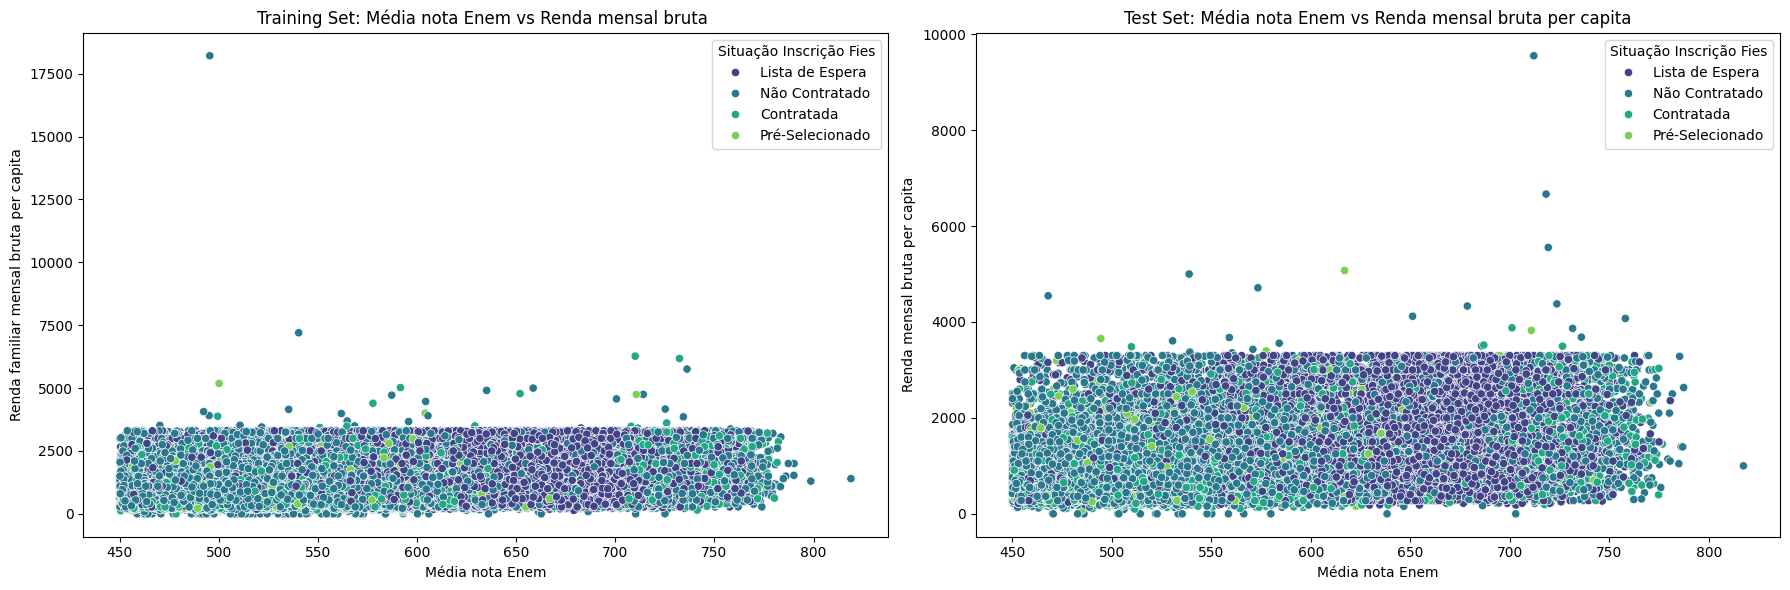

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scatter plot for training data
sns.scatterplot(x='Média nota Enem', y='Renda mensal bruta per capita', data=tmpdata, hue='Situação Inscrição Fies', palette='viridis', ax=axes[0])
axes[0].set_title('Training Set: Média nota Enem vs Renda mensal bruta ')
axes[0].set_xlabel('Média nota Enem')
axes[0].set_ylabel('Renda familiar mensal bruta per capita')
axes[0].legend(title='Situação Inscrição Fies')

# Scatter plot for test data
sns.scatterplot(x='Média nota Enem', y='Renda mensal bruta per capita', data=tmpdataTwo, hue='Situação Inscrição Fies', palette='viridis', ax=axes[1])
axes[1].set_title('Test Set: Média nota Enem vs Renda mensal bruta per capita')
axes[1].set_xlabel('Média nota Enem')
axes[1].set_ylabel('Renda mensal bruta per capita')
axes[1].legend(title='Situação Inscrição Fies')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4059/2157112528.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


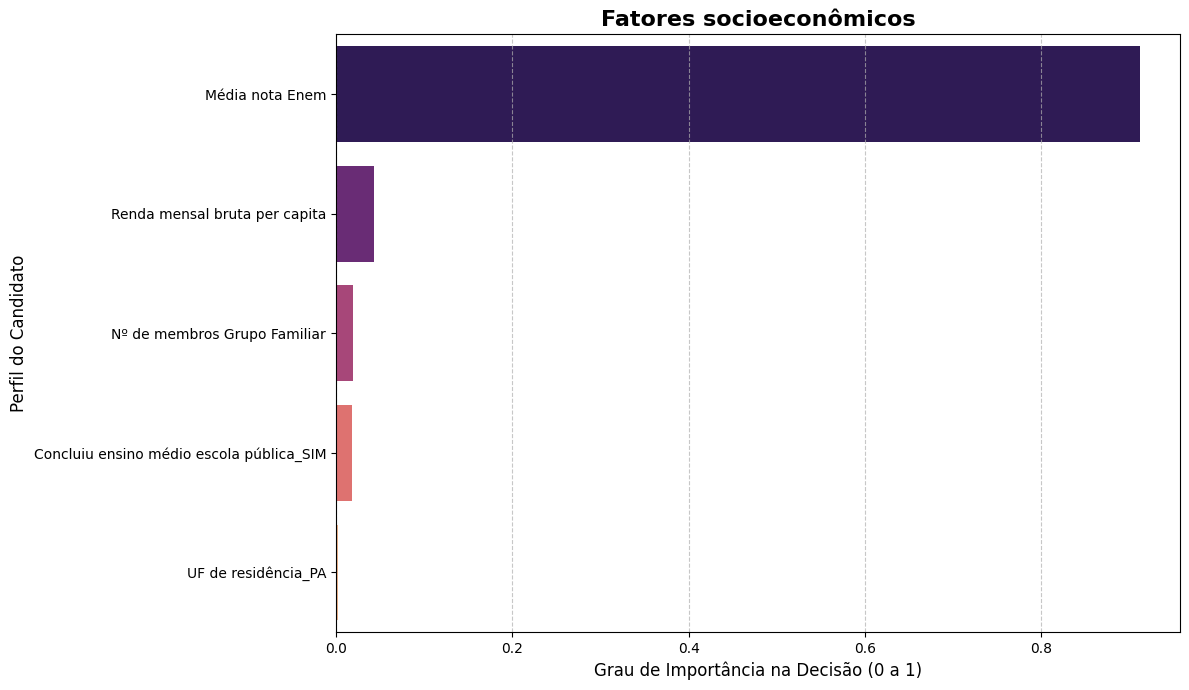

In [21]:
importancias = clf_tree_social.feature_importances_
nomes_features = Z_train.columns

# 2. Criando um DataFrame para organizar do maior para o menor
df_importancia = pd.DataFrame({
    'Atributo': nomes_features,
    'Peso_Matemático': importancias
})

# Vamos pegar apenas os 10 atributos mais fortes para o gráfico não ficar poluído
df_importancia = df_importancia.sort_values(by='Peso_Matemático', ascending=False).head(5)

# 3. Plotando o gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_importancia,
    x='Peso_Matemático',
    y='Atributo',
    palette='magma' # Uma paleta de cores forte para dar impacto visual
)

# 4. Ajustes estéticos para o slide
plt.title("Fatores socioeconômicos", fontsize=16, fontweight='bold')
plt.xlabel("Grau de Importância na Decisão (0 a 1)", fontsize=12)
plt.ylabel("Perfil do Candidato", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Exibe o gráfico
plt.show()

**KNN** (K-Nearest Neighbors)

In [22]:
# Futuramente?